In [375]:
%load_ext autoreload
%autoreload 2

# Other useful imports
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.signal as signal
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA, FastICA
import time
from scipy.signal import welch
from IPython.display import clear_output
import scipy.stats as stats

# Spyeeg import
from spyeeg.generate import simulate_channels, simulate_multisensory_channels, simulate_continuous_stimuli, simulate_PAC
import spyeeg.models as models


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [301]:
mpl.rcParams.update(mpl.rcParamsDefault)

%matplotlib inline
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["b", "r", "g"])
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.linewidth'] = 0.4
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['font.size'] = 3.5
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['grid.alpha'] = 0.4
mpl.rcParams['grid.linewidth'] = 0.2
mpl.rcParams['lines.linewidth'] = 0.6


In [583]:
# Generate the Data without noise
fs = 50
n_feat = 2
n_channels = 2
T = 300
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = np.inf, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 0)


_, X_noise, Y_noise, _, _ = simulate_channels(n_feat = n_feat, n_channels = 30, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = -50, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 10)


In [584]:
Yadd = np.zeros((Y.shape[0], 5))

for i in range(Yadd.shape[1]):
    for j in range(Y.shape[1]):
        Yadd[:,i] += Y[:,j] * np.random.random() 
    Yadd[:,i] += Y_noise[:,i]


Y = scale(Yadd)

In [585]:
tmin, tmax = -.5, 1
alphas = [0] + list(np.logspace(-3,3,20))
lam_list = [1500]
n_folds = 5
metrics = 'R2'

In [586]:
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')

# Now, we can fit the data using cross-fold validation
scores_trf = trf.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False).mean(0)

### Classic RRR

In [527]:
scores_rrr = []
for lam in lam_list:
    rrr = models.RRR.RRREstimator(tmin=tmin, tmax=tmax, srate = fs, lam = lam, tol=1e-7)

    # Now, we can fit the data using cross-fold validation
    scores_rrr.append(rrr.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False).mean(0))

5


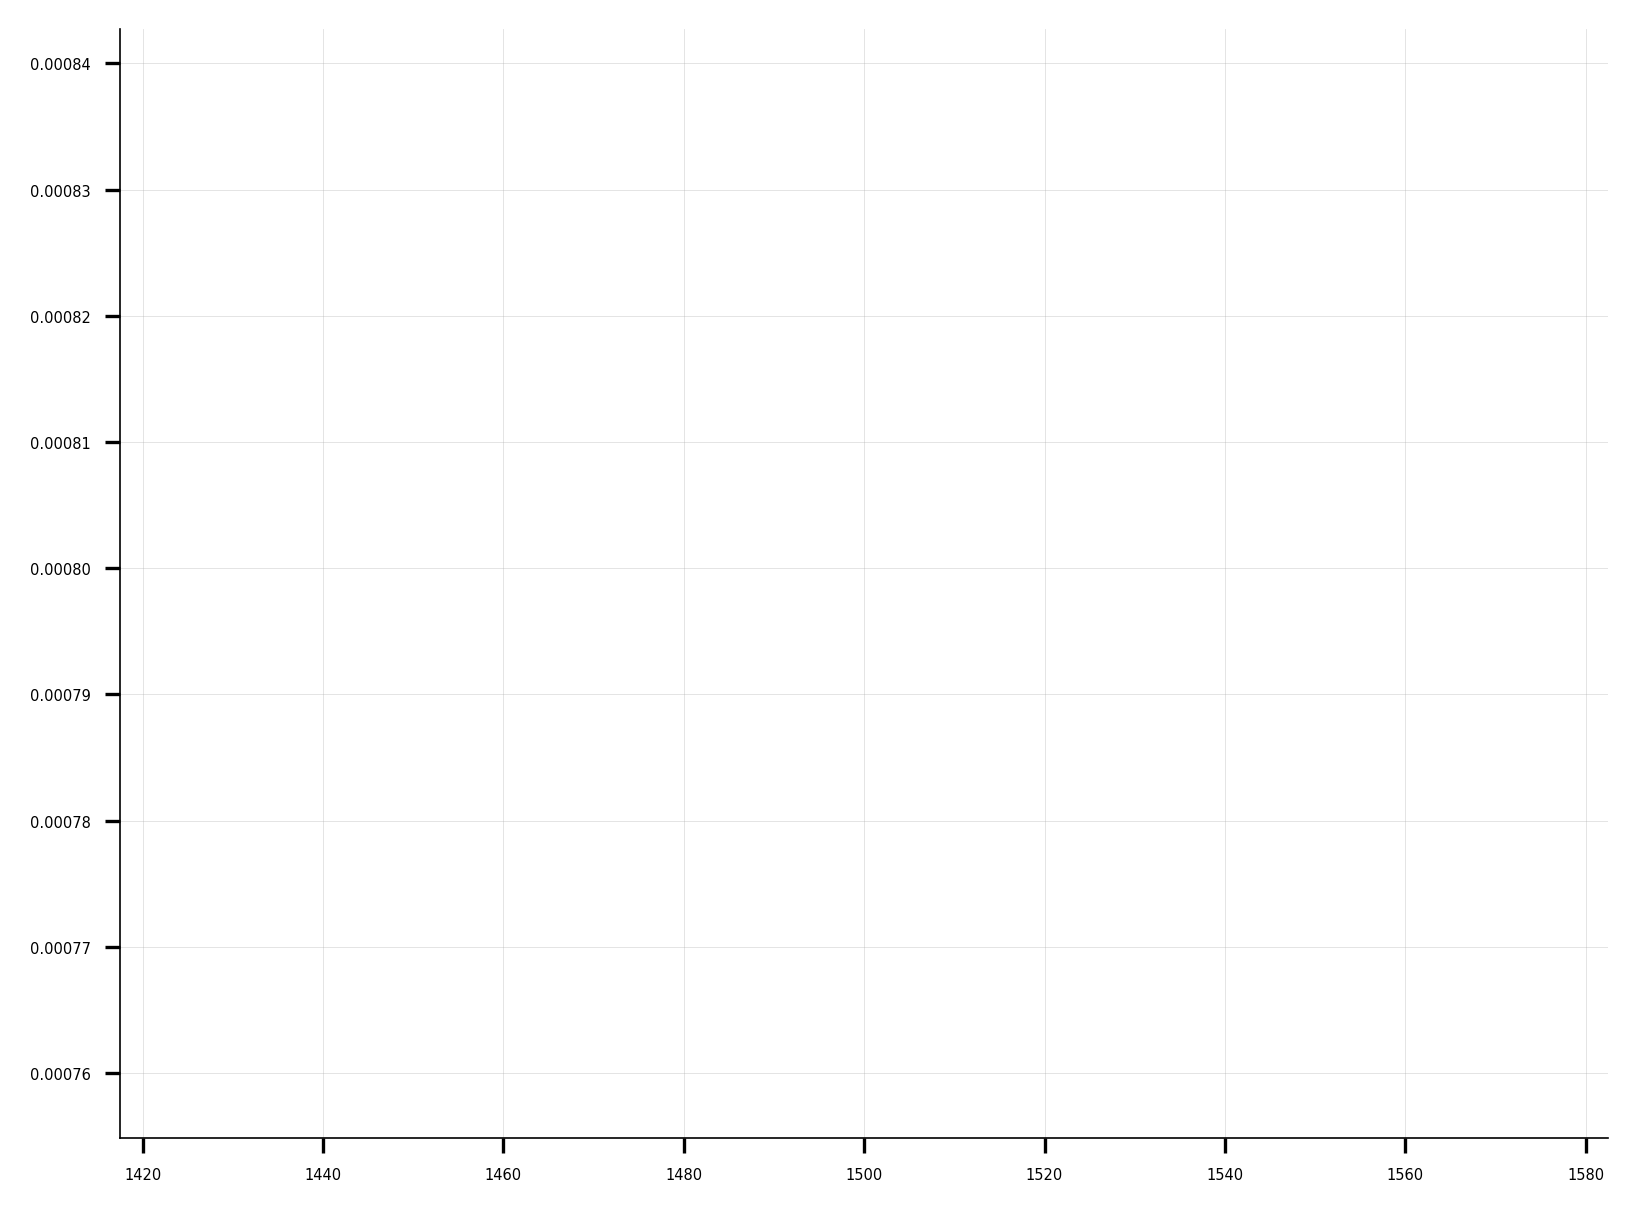

In [528]:
plt.plot(lam_list,np.asarray(scores_rrr).mean(1) - scores_trf.max(1).mean())
print(rrr.rank)

In [529]:
B1 = trf.get_coef()
B2 = rrr.get_coef()

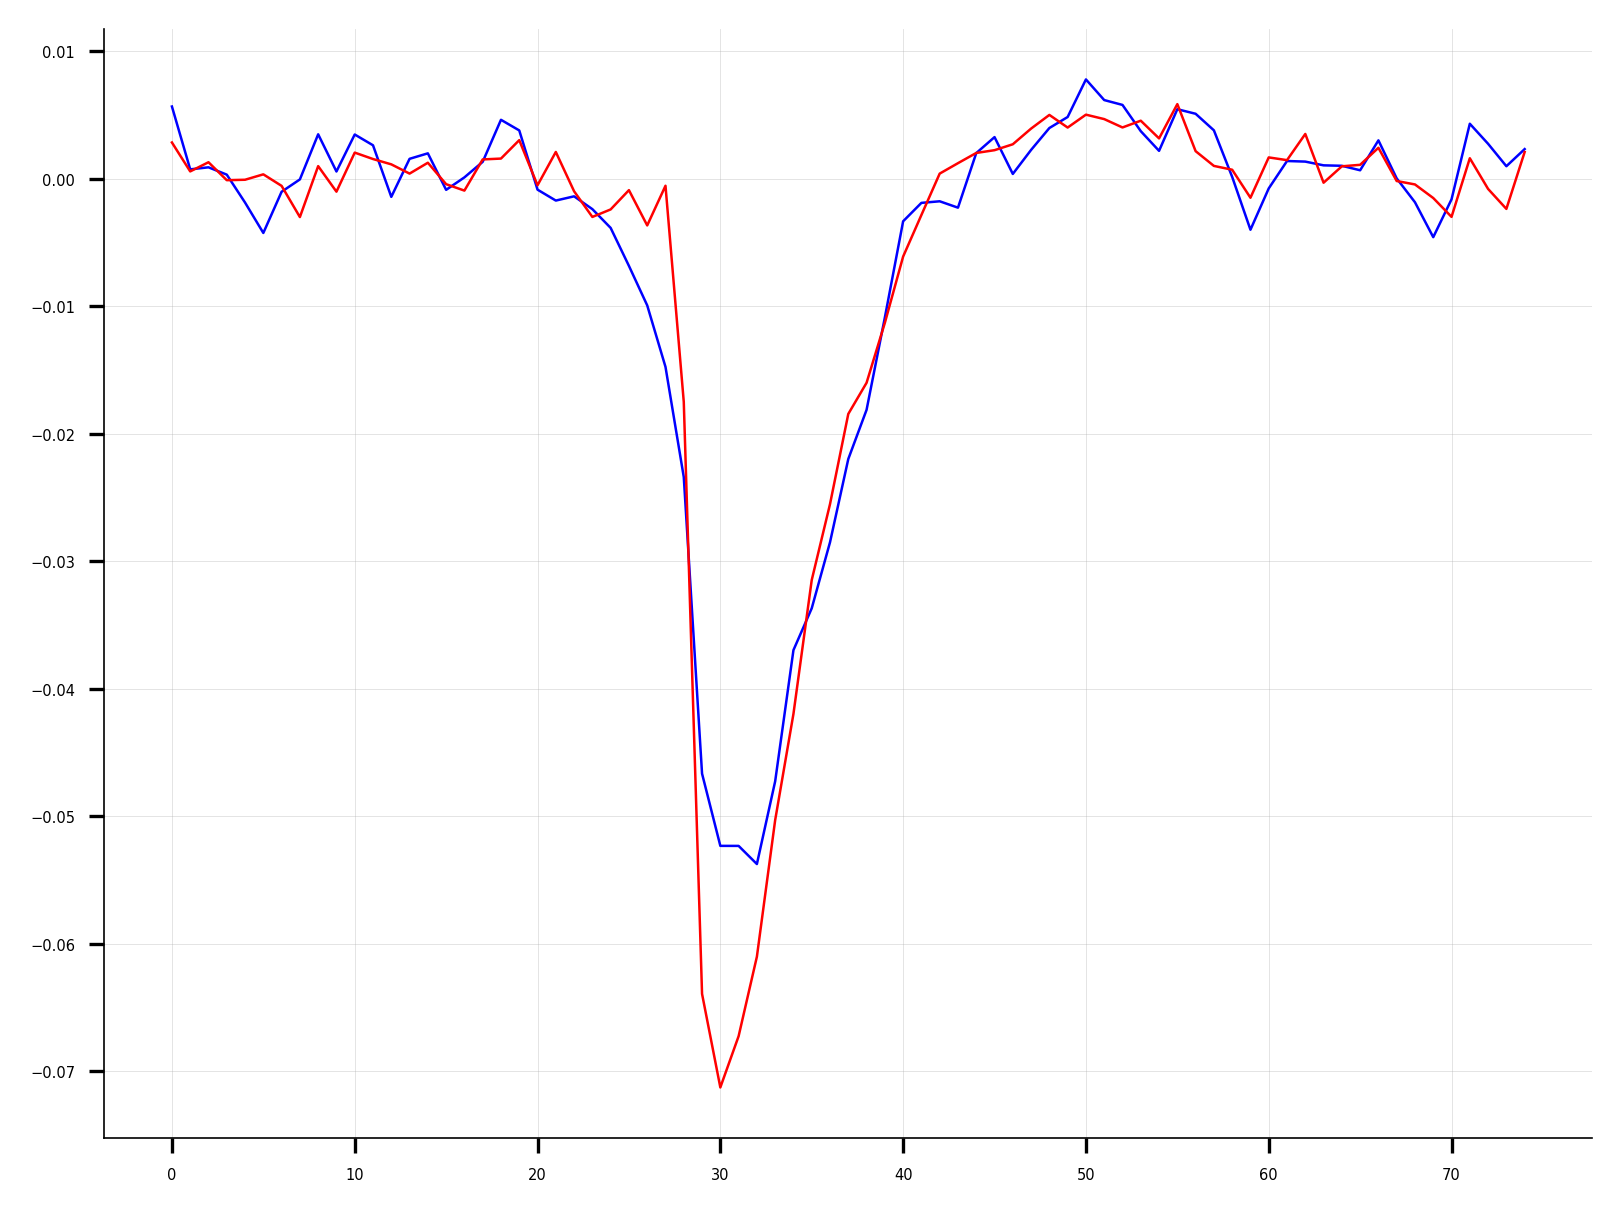

In [531]:
plt.plot(B1[:,0,0,10])
plt.plot(B2[:,0,0])

### iRRR (blockwise)

In [620]:
# Generate the Data without noise
fs = 50
n_feat = 1
n_channels = 2
T = 300
time_array, X_1, Y_1, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = np.inf, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 0)

time_array, X_2, Y_2, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = np.inf, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 5)


_, X_noise, Y_noise, _, _ = simulate_channels(n_feat = n_feat, n_channels = 30, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = -50, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 10)

X = np.hstack([X_1,X_2])


In [621]:
Yadd = np.zeros((Y_1.shape[0], 5))

for i in range(Yadd.shape[1]):
    for j in range(Y_1.shape[1]):
        if j%2 == 0:
            Yadd[:,i] += (Y_1[:,j] + Y_2[:,j]) * np.random.random() 
        else:
            Yadd[:,i] += Y_1[:,j] * np.random.random() 
    Yadd[:,i] += Y_noise[:,i]


Y = scale(Yadd)

In [622]:
tmin, tmax = -.5, 1
alphas = [0] + list(np.logspace(-3,3,20))
lam_list = [1500]
n_folds = 5
metrics = 'R2'

In [623]:
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')

# Now, we can fit the data using cross-fold validation
scores_trf = trf.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False).mean(0)

In [624]:
scores_trf.max(-1)

array([0.23986598, 0.5354576 , 0.34681947, 0.16482278, 0.57476387])

In [625]:
import numpy as np
from spyeeg.models._methods import _soft_threshold_singular_values, _spectral_norm_sq_power


def fit_iRRR_fista(
    X_blocks,
    Y,
    lam_blocks,
    *,
    max_iter: int = 500,
    tol: float = 1e-5,
    step: float | None = None,
    power_iter: int = 30,
    fista_restart: bool = True,
    center_X: bool = False,
    center_Y: bool = True,
    verbose: bool = False,
):
    """
    Integrated RRR (multi-block nuclear norm) via FISTA:

        min_{B_k} 0.5 || Y - sum_k X_k B_k ||_F^2  +  sum_k lam_k ||B_k||_*

    Parameters
    ----------
    X_blocks : list of ndarray
        Each X_k has shape (T, d_k). (Already includes lags if you want.)
    Y : ndarray
        Shape (T, p) outputs (channels).
    lam_blocks : float or list/ndarray
        If float, shared lambda across blocks; else length K.

    Returns
    -------
    B_blocks : list of ndarray
        Each B_k has shape (d_k, p).
    info : dict
        Contains objective history, ranks per block per iter, step size, means, etc.
    """
    # --- validate / coerce ---
    if not isinstance(X_blocks, (list, tuple)) or len(X_blocks) == 0:
        raise ValueError("X_blocks must be a non-empty list/tuple of design matrices.")
    X_blocks = [np.asarray(Xk, dtype=float) for Xk in X_blocks]
    Y = np.asarray(Y, dtype=float)

    T = X_blocks[0].shape[0]
    for k, Xk in enumerate(X_blocks):
        if Xk.ndim != 2:
            raise ValueError(f"X_blocks[{k}] must be 2D, got {Xk.shape}.")
        if Xk.shape[0] != T:
            raise ValueError("All X_k must have the same number of rows (T).")
    if Y.ndim != 2 or Y.shape[0] != T:
        raise ValueError(f"Y must be 2D with shape (T, p). Got {Y.shape}.")

    K = len(X_blocks)
    p = Y.shape[1]
    d_blocks = [Xk.shape[1] for Xk in X_blocks]

    if np.isscalar(lam_blocks):
        lam = [float(lam_blocks)] * K
    else:
        lam = list(np.asarray(lam_blocks, dtype=float).ravel())
        if len(lam) != K:
            raise ValueError(f"lam_blocks must have length K={K}, got {len(lam)}.")

    # --- centering ---
    X_means = []
    Xc_blocks = []
    for Xk in X_blocks:
        mk = Xk.mean(axis=0, keepdims=True) if center_X else np.zeros((1, Xk.shape[1]))
        X_means.append(mk)
        Xc_blocks.append(Xk - mk)

    Y_mean = Y.mean(axis=0, keepdims=True) if center_Y else np.zeros((1, p))
    Yc = Y - Y_mean

    # --- step size ---
    # Lipschitz constant of gradient of smooth term:
    # L = || sum_k X_k^T X_k ||_2 <= sum_k ||X_k||_2^2
    if step is None:
        L_est = 0.0
        for k, Xk in enumerate(Xc_blocks):
            L_est += _spectral_norm_sq_power(Xk, n_iter=power_iter, seed=k)
        if L_est <= 1e-12:
            # Degenerate case
            B0 = [np.zeros((d_blocks[k], p)) for k in range(K)]
            return B0, {
                "obj": [0.5 * np.linalg.norm(Yc, "fro") ** 2],
                "ranks": [[0] * K],
                "step": np.inf,
                "X_means": X_means,
                "Y_mean": Y_mean,
                "center_X": center_X,
                "center_Y": center_Y,
            }
        step = 1.0 / L_est
    step = float(step)

    # --- initialize ---
    B = [np.zeros((d_blocks[k], p)) for k in range(K)]
    Z = [Bk.copy() for Bk in B]
    t = 1.0

    # Residual for Z: Rz = sum_k Xk Zk - Y
    Rz = -Yc.copy()
    for k in range(K):
        Rz += Xc_blocks[k] @ Z[k]

    obj_hist = []
    ranks_hist = []

    def objective(B_list):
        R = -Yc.copy()
        nuc = 0.0
        for k in range(K):
            R += Xc_blocks[k] @ B_list[k]
            nuc += lam[k] * np.sum(np.linalg.svd(B_list[k], compute_uv=False))
        return 0.5 * np.linalg.norm(R, "fro") ** 2 + nuc

    prev_obj = None

    for it in range(1, max_iter + 1):
        B_next = []
        ranks_this = []

        # We will update prox for each block using the *same* gradient point Z.
        # Efficient gradients: Gk = Xk^T Rz where Rz = sum_j Xj Zj - Y.
        for k in range(K):
            Gk = Xc_blocks[k].T @ Rz
            Mk = Z[k] - step * Gk
            Bk_new, rk, s_th = _soft_threshold_singular_values(Mk, tau=step * lam[k])
            B_next.append(Bk_new)
            ranks_this.append(rk)

        # FISTA momentum
        t_next = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        Z_next = []
        for k in range(K):
            Zk_new = B_next[k] + ((t - 1.0) / t_next) * (B_next[k] - B[k])
            Z_next.append(Zk_new)

        # Optional restart (common/simple criterion)
        if fista_restart:
            # A lightweight restart check: if objective increases, restart momentum.
            obj_try = objective(B_next)
            if prev_obj is not None and obj_try > prev_obj:
                t_next = 1.0
                Z_next = [Bk.copy() for Bk in B_next]
                obj = objective(B_next)
            else:
                obj = obj_try
        else:
            obj = objective(B_next)

        obj_hist.append(obj)
        ranks_hist.append(ranks_this)

        # Convergence
        if prev_obj is not None:
            rel_obj = abs(prev_obj - obj) / (abs(prev_obj) + 1e-12)
            rel_step = 0.0
            denom = 0.0
            for k in range(K):
                rel_step += np.linalg.norm(B_next[k] - B[k], "fro") ** 2
                denom += np.linalg.norm(B[k], "fro") ** 2
            rel_step = np.sqrt(rel_step) / (np.sqrt(denom) + 1e-12)

            if verbose and (it == 1 or it % 25 == 0):
                print(f"iter {it:4d}  obj={obj:.6e}  ranks={ranks_this}  rel_obj={rel_obj:.2e}  rel_step={rel_step:.2e}")

            if (rel_obj < tol) and (rel_step < np.sqrt(tol)):
                B, Z, t = B_next, Z_next, t_next
                break
        else:
            if verbose:
                print(f"iter {it:4d}  obj={obj:.6e}  ranks={ranks_this}")

        # Update state and residual for next iteration
        B, Z, t = B_next, Z_next, t_next
        Rz = -Yc.copy()
        for k in range(K):
            Rz += Xc_blocks[k] @ Z[k]
        prev_obj = obj

    info = {
        "obj": obj_hist,
        "ranks": ranks_hist,          # list of [rank_k] per iter
        "step": step,
        "X_means": X_means,           # list of (1, d_k)
        "Y_mean": Y_mean,             # (1, p)
        "center_X": center_X,
        "center_Y": center_Y,
        "n_iter": len(obj_hist),
        "lam": lam,
    }
    return B, info


In [626]:
X2, Y2 = trf.get_XY(X, Y)
X3 = X2.reshape(X2.shape[0],75,2)
X_blocks = list(np.moveaxis(X3, 2, 0))

In [627]:
# X_blocks: e.g. [X_env_lags, X_phon_lags, X_sem_lags]
B_blocks, info = fit_iRRR_fista(X_blocks, Y2, lam_blocks=[100.0, 100.0], verbose=True)

# Predict (remember centering, if enabled)
Yhat = info["Y_mean"].copy()
R = 0.0
for Xk, Bk, mk in zip(X_blocks, B_blocks, info["X_means"]):
    Xkc = Xk - mk
    R += Xkc @ Bk
Yhat = R + info["Y_mean"]


iter    1  obj=3.076137e+04  ranks=[5, 5]
iter   25  obj=2.302768e+04  ranks=[5, 5]  rel_obj=1.08e-03  rel_step=3.16e-02
iter   50  obj=2.292330e+04  ranks=[5, 5]  rel_obj=8.14e-05  rel_step=8.70e-03
iter   75  obj=2.291223e+04  ranks=[5, 5]  rel_obj=8.04e-06  rel_step=4.07e-03


In [628]:
stats.pearsonr(Yhat, Y2)

PearsonRResult(statistic=array([0.50761934, 0.7410708 , 0.60985578, 0.43435809, 0.76899189]), pvalue=array([0., 0., 0., 0., 0.]))

In [634]:
np.random.choice(np.arange(1,17),16, replace=False).reshape(4,4)

array([[ 3,  6, 15, 12],
       [ 4,  8, 13, 10],
       [ 2,  7, 16,  5],
       [14,  9,  1, 11]])

In [664]:
grid = np.array([[6,5,4],
                  [1,3,2],
                   [8,7,9]])

def check_grid(grid, value = 15):
    check = True
    for i in range(3):
        if np.sum(grid[i,:]) != value or np.sum(grid[:,i]) != value:
            check = False
    if (grid[0,0] + grid[1,1] + grid[2,2]) != value and (grid[0,2] + grid[1,1] + grid[2,0]) != value:
        check = False
    return check

In [640]:
grid = np.array([[6,5,4],
                  [1,3,2],
                   [8,7,9]])

check_grid(grid)

True

In [668]:
permutations = []
for i in range(9):
    for j in range(i+1,9):
        permutations.append((i,j))

for i in range(len(permutations)):
    for j in range(len(permutations)):
        for k in range(len(permutations)):
            perm1 = permutations[i]
            perm2 = permutations[j]
            perm3 = permutations[k]
            new_grid = grid.copy()

            i1,j1,i2,j2 = perm1[0]//3, perm1[0]%3, perm1[1]//3, perm1[1]%3
            val1, val2 = grid[i1,j1], grid[i2,j2]

            new_grid[i1,j1] = val2
            new_grid[i2,j2] = val1

            i1,j1,i2,j2 = perm2[0]//3, perm2[0]%3, perm2[1]//3, perm2[1]%3
            val1, val2 = grid[i1,j1], grid[i2,j2]

            new_grid[i1,j1] = val2
            new_grid[i2,j2] = val1

            if check_grid(new_grid):
                print('jambon')
        


In [663]:
permutations

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 8),
 (4, 5),
 (4, 6),
 (4, 7),
 (4, 8),
 (5, 6),
 (5, 7),
 (5, 8),
 (6, 7),
 (6, 8),
 (7, 8)]

In [661]:
grid[i2,j2]

np.int64(8)